Replication + Bootstrap Analysis
Zhang et al. (2019) - Variable Discretization & Cost-Sensitive Logistic Regression
===================================================================================
Run blocks sequentially. Each block is self-contained but depends on the ones above.

BLOCK ORDER:
  0. Imports & config
  1. Data loading & cleaning
  2. Discretization (quantile binning + one-hot encoding)
  3. Model definitions
  4. Phase 2 — Replicate paper (10-fold CV, Tables 6 & 9)
  5. Phase 3 — Bootstrap point estimates + CIs
  6. Phase 4 — Bootstrap model selection (.632+ rule)
  7. Summary comparison table

In [13]:
# =============================================================================
# BLOCK 0 — Imports & config
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix
)
from scipy import stats

SEED       = 42
B          = 1000   # bootstrap replicates (set to 200 first to test, then 1000)
N_BINS     = 20     # max bins for quantile discretization (paper uses 20)
CV_FOLDS   = 10
LR_SOLVER  = 'lbfgs'
LR_MAX_ITER = 2000

rng = np.random.default_rng(SEED)

print("Block 0 done: imports loaded.")

Block 0 done: imports loaded.


In [14]:
# =============================================================================
# BLOCK 1 — Data loading & cleaning
# =============================================================================
df = pd.read_csv("GiveMeSomeCredit/cs-training.csv")

y_full = df['SeriousDlqin2yrs']
X_full = df.drop(columns=['SeriousDlqin2yrs'])

if 'Unnamed: 0' in X_full.columns:
    X_full = X_full.drop(columns=['Unnamed: 0'])

# --- Drop rows with any missing value (MCAR, matches paper for Models 1-4) ---
mask_clean  = X_full.notna().all(axis=1)
X_clean     = X_full.loc[mask_clean].reset_index(drop=True)
y_clean     = y_full.loc[mask_clean].reset_index(drop=True)

print(f"\nOriginal rows : {len(df):,}")
print(f"After dropna  : {len(X_clean):,}")
print(f"Event rate    : {y_clean.mean()*100:.2f}%  (paper reports ~6.95%)")

# --- 70 / 30 stratified split (matches paper) ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.30,
    stratify=y_clean,
    random_state=SEED
)

print(f"\nTrain size : {len(X_train):,}  |  event rate: {y_train.mean()*100:.2f}%")
print(f"Test  size : {len(X_test):,}   |  event rate: {y_test.mean()*100:.2f}%")

# --- Variables selected by paper (IV > 0.1) ---
SELECTED_VARS = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'age',
]

# Confirm columns exist (Kaggle CSV may use different capitalisation)
available = X_clean.columns.tolist()
SELECTED_VARS = [v for v in SELECTED_VARS if v in available]
print(f"\nSelected variables (IV>0.1) found: {SELECTED_VARS}")

print("\nBlock 1 done: data loaded and split.")




Original rows : 150,000
After dropna  : 120,269
Event rate    : 6.95%  (paper reports ~6.95%)

Train size : 84,188  |  event rate: 6.95%
Test  size : 36,081   |  event rate: 6.95%

Selected variables (IV>0.1) found: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'age']

Block 1 done: data loaded and split.


In [15]:
# =============================================================================
# BLOCK 2 — Discretization (quantile binning + one-hot encoding)
# =============================================================================
# Quantile discretize each selected variable into up to N_BINS bins,
# then one-hot encode — matches paper Section 3.2.

def make_discretized(X_tr, X_te, cols, n_bins=N_BINS):
    """
    Returns (X_tr_disc, X_te_disc) as dense arrays after
    quantile binning + one-hot encoding on `cols`.
    """
    disc = KBinsDiscretizer(
        n_bins=n_bins,
        encode='ordinal',       # ordinal first, then OHE below
        strategy='quantile',
        subsample=None
    )
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    X_tr_binned = disc.fit_transform(X_tr[cols])
    X_te_binned = disc.transform(X_te[cols])

    X_tr_ohe = ohe.fit_transform(X_tr_binned)
    X_te_ohe = ohe.transform(X_te_binned)

    return X_tr_ohe, X_te_ohe, disc, ohe

# Build the four data representations used by the four models
X_tr_all  = X_train[X_clean.columns]           # all original vars (Model 1)
X_te_all  = X_test[X_clean.columns]

X_tr_sel  = X_train[SELECTED_VARS]             # selected original vars (Model 2 & 3)
X_te_sel  = X_test[SELECTED_VARS]

X_tr_disc, X_te_disc, disc_fitted, ohe_fitted = make_discretized(
    X_train, X_test, SELECTED_VARS            # discretized selected vars (Model 4)
)

print(f"Model 1 feature shape : {X_tr_all.shape}")
print(f"Model 2/3 feature shape: {X_tr_sel.shape}")
print(f"Model 4 feature shape : {X_tr_disc.shape}  (one-hot bins)")

print("\nBlock 2 done: discretization complete.")

Model 1 feature shape : (84188, 10)
Model 2/3 feature shape: (84188, 5)
Model 4 feature shape : (84188, 46)  (one-hot bins)

Block 2 done: discretization complete.


In [16]:
# =============================================================================
# BLOCK 3 — Model definitions
# =============================================================================
# Paper uses:
#   Model 1 : standard LR, all original variables
#   Model 2 : standard LR, selected variables (IV > 0.1)
#   Model 3 : cost-sensitive LR (class_weight), selected variables
#             best tau=0.5 → W1=7.19, W0=0.54  (paper Figure 2)
#   Model 4 : standard LR, discretized+OHE selected variables

# Class weights for Model 3 — derived from paper Equation (3)
# W1 = tau / y_bar,  W0 = (1-tau) / (1-y_bar)
tau   = 0.50
y_bar = y_train.mean()
W1    = tau / y_bar
W0    = (1 - tau) / (1 - y_bar)
print(f"Model 3 class weights: W0={W0:.3f}, W1={W1:.3f}  (paper: W0≈0.54, W1≈7.19)")

def make_lr(class_weight=None):
    return LogisticRegression(
        solver=LR_SOLVER,
        max_iter=LR_MAX_ITER,
        class_weight=class_weight,
        random_state=SEED
    )

MODELS = {
    'Model 1': (make_lr(),             X_tr_all,  X_te_all),
    'Model 2': (make_lr(),             X_tr_sel,  X_te_sel),
    'Model 3': (make_lr({0: W0, 1: W1}), X_tr_sel, X_te_sel),
    'Model 4': (make_lr(),             X_tr_disc, X_te_disc),
}

print("\nBlock 3 done: models defined.")

Model 3 class weights: W0=0.537, W1=7.196  (paper: W0≈0.54, W1≈7.19)

Block 3 done: models defined.


In [17]:
# =============================================================================
# BLOCK 4 — Phase 2: Replicate paper (10-fold stratified CV)
# =============================================================================
def best_cutoff_metrics(y_true, y_prob):
    """
    Probability cutoff = intersection of sensitivity & specificity curves.
    Approximated by maximising |sensitivity - specificity| minimisation,
    i.e. the Youden J point — close to paper's method (Section 4).
    """
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    spec = 1 - fpr
    j_idx = np.argmax(tpr + spec - 1)           # Youden J
    cutoff = thresholds[j_idx]

    y_pred = (y_prob >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    type1 = fp / (fp + tn)   # false positive rate (1 - specificity)
    type2 = fn / (fn + tp)   # false negative rate (1 - sensitivity)
    acc   = (tp + tn) / len(y_true)
    f1    = f1_score(y_true, y_pred)
    return {'cutoff': cutoff, 'type1': type1, 'type2': type2,
            'accuracy': acc, 'f1': f1}

print("\n" + "="*60)
print("PHASE 2 — 10-fold CV replication (Table 6 & Table 9)")
print("="*60)

paper_table6 = {'Model 1': 0.69, 'Model 2': 0.68, 'Model 3': 0.79, 'Model 4': 0.83}
cv_results = {}

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

for name, (clf, X_tr, X_te) in MODELS.items():
    aucs = cross_val_score(clf, X_tr, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = aucs

    # Fit on full training set, evaluate on test set
    clf.fit(X_tr, y_train)
    y_prob_test = clf.predict_proba(X_te)[:, 1]
    test_auc    = roc_auc_score(y_test, y_prob_test)
    metrics     = best_cutoff_metrics(y_test, y_prob_test)

    print(f"\n{name}")
    print(f"  CV AUC  : {aucs.mean():.4f} ± {aucs.std():.4f}  "
          f"(paper: {paper_table6[name]:.2f})")
    print(f"  Test AUC: {test_auc:.4f}")
    print(f"  Type I  : {metrics['type1']*100:.2f}%   "
          f"Type II: {metrics['type2']*100:.2f}%")
    print(f"  Accuracy: {metrics['accuracy']*100:.2f}%   "
          f"F1: {metrics['f1']:.4f}   Cutoff: {metrics['cutoff']:.4f}")

print("\nBlock 4 done: replication complete.")


PHASE 2 — 10-fold CV replication (Table 6 & Table 9)

Model 1
  CV AUC  : 0.6916 ± 0.0191  (paper: 0.69)
  Test AUC: 0.6860
  Type I  : 15.22%   Type II: 53.89%
  Accuracy: 82.09%   F1: 0.2635   Cutoff: 0.0911

Model 2
  CV AUC  : 0.6839 ± 0.0210  (paper: 0.68)
  Test AUC: 0.6762
  Type I  : 15.10%   Type II: 55.72%
  Accuracy: 82.08%   F1: 0.2556   Cutoff: 0.0900

Model 3
  CV AUC  : 0.7910 ± 0.0152  (paper: 0.79)
  Test AUC: 0.7846
  Type I  : 15.51%   Type II: 41.16%
  Accuracy: 82.71%   F1: 0.3210   Cutoff: 0.5091

Model 4
  CV AUC  : 0.8410 ± 0.0101  (paper: 0.83)
  Test AUC: 0.8409
  Type I  : 26.43%   Type II: 21.10%
  Accuracy: 73.94%   F1: 0.2962   Cutoff: 0.0565

Block 4 done: replication complete.


In [ ]:
# =============================================================================
# BLOCK 5 — Phase 3: Bootstrap point estimates + CIs  (stratified, B replicates)
# =============================================================================
# Stratified bootstrap: sample minority and majority class SEPARATELY
# then concatenate — guarantees event rate is preserved in every replicate.
# Critical here because event rate is only ~6.95%.

from tqdm import tqdm

B=200
print("\n" + "="*60)
print(f"PHASE 3 — Stratified bootstrap estimation  (B={B})")
print("="*60)
n_train      = len(X_train)
metrics_keys = ['auc', 'f1', 'type1', 'type2']

boot_metrics = {
    name: {k: np.zeros(B) for k in metrics_keys}
    for name in MODELS
}

# Pre-convert to numpy for speed inside the loop
data_arrays = {
    'Model 1': (X_tr_all.values,  X_te_all.values),
    'Model 2': (X_tr_sel.values,  X_te_sel.values),
    'Model 3': (X_tr_sel.values,  X_te_sel.values),
    'Model 4': (X_tr_disc,        X_te_disc),
}
y_train_arr = y_train.values
y_test_arr  = y_test.values

# Stratified bootstrap: pre-compute class indices once
minority_idx = np.where(y_train_arr == 1)[0]   # events
majority_idx = np.where(y_train_arr == 0)[0]   # non-events

n_minority   = len(minority_idx)
n_majority   = len(majority_idx)

print(f"  Minority class (events)    : {n_minority:,}  ({n_minority/n_train*100:.2f}%)")
print(f"  Majority class (non-events): {n_majority:,}  ({n_majority/n_train*100:.2f}%)")
print(f"  Each replicate draws {n_minority:,} + {n_majority:,} = {n_train:,} rows\n")

skipped = 0

for b in tqdm(range(B), desc="Bootstrap replicates", unit="rep"):

    # --- Stratified resample: sample each class independently ---
    boot_min = rng.choice(minority_idx, size=n_minority, replace=True)
    boot_maj = rng.choice(majority_idx, size=n_majority, replace=True)
    boot_idx = np.concatenate([boot_min, boot_maj])

    # Sanity check: both classes must be present (always true with stratified,
    # but guard anyway in case of extreme edge cases)
    if len(np.unique(y_train_arr[boot_idx])) < 2:
        skipped += 1
        continue

    for name in MODELS:
        X_tr_b, X_te_b = data_arrays[name]

        X_boot = X_tr_b[boot_idx]
        y_boot = y_train_arr[boot_idx]

        clf_b = make_lr({0: W0, 1: W1}) if name == 'Model 3' else make_lr()
        clf_b.fit(X_boot, y_boot)

        y_prob = clf_b.predict_proba(X_te_b)[:, 1]

        auc = roc_auc_score(y_test_arr, y_prob)
        m   = best_cutoff_metrics(y_test_arr, y_prob)

        boot_metrics[name]['auc'][b]   = auc
        boot_metrics[name]['f1'][b]    = m['f1']
        boot_metrics[name]['type1'][b] = m['type1']
        boot_metrics[name]['type2'][b] = m['type2']

if skipped:
    print(f"\n  Warning: {skipped} replicates skipped (single-class draw).")

# --- Point estimates and 95% percentile CIs ---
print("\n--- Bootstrap point estimates and 95% percentile CIs ---")
boot_summary = {}

for name in MODELS:
    boot_summary[name] = {}
    print(f"\n{name}")
    for k in metrics_keys:
        vals = boot_metrics[name][k]
        mean = vals.mean()
        lo   = np.percentile(vals, 2.5)
        hi   = np.percentile(vals, 97.5)
        boot_summary[name][k] = (mean, lo, hi)
        label = {'auc': 'AUC', 'f1': 'F1',
                 'type1': 'Type I', 'type2': 'Type II'}[k]
        print(f"  {label:8s}: {mean:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

# --- Key comparison: AUC difference M4 - M3 ---
diff_m4_m3 = boot_metrics['Model 4']['auc'] - boot_metrics['Model 3']['auc']
diff_mean  = diff_m4_m3.mean()
diff_lo    = np.percentile(diff_m4_m3, 2.5)
diff_hi    = np.percentile(diff_m4_m3, 97.5)

print(f"\nAUC difference (Model 4 - Model 3):")
print(f"  Mean = {diff_mean:.4f}  95% CI [{diff_lo:.4f}, {diff_hi:.4f}]")
if diff_lo > 0:
    print("  → CI excludes zero: discretization advantage is statistically supported.")
else:
    print("  → CI includes zero: gap is within bootstrap sampling noise.")

print("\nBlock 5 done: stratified bootstrap estimation complete.")


PHASE 3 — Stratified bootstrap estimation  (B=200)
  Minority class (events)    : 5,850  (6.95%)
  Majority class (non-events): 78,338  (93.05%)
  Each replicate draws 5,850 + 78,338 = 84,188 rows



Bootstrap replicates:   0%|          | 0/200 [00:00<?, ?rep/s]

Bootstrap replicates: 100%|██████████| 200/200 [1:03:30<00:00, 19.05s/rep]


--- Bootstrap point estimates and 95% percentile CIs ---

Model 1
  AUC     : 0.6846  95% CI [0.6804, 0.6874]
  F1      : 0.2525  95% CI [0.2286, 0.2682]
  Type I  : 0.1686  95% CI [0.1356, 0.2241]
  Type II : 0.5310  95% CI [0.4926, 0.5665]

Model 2
  AUC     : 0.6768  95% CI [0.6753, 0.6794]
  F1      : 0.2549  95% CI [0.2476, 0.2615]
  Type I  : 0.1538  95% CI [0.1411, 0.1676]
  Type II : 0.5534  95% CI [0.5404, 0.5704]

Model 3
  AUC     : 0.7851  95% CI [0.7785, 0.7907]
  F1      : 0.3077  95% CI [0.2849, 0.3216]
  Type I  : 0.1764  95% CI [0.1543, 0.1988]
  Type II : 0.3893  95% CI [0.3662, 0.4169]

Model 4
  AUC     : 0.8400  95% CI [0.8389, 0.8411]
  F1      : 0.2966  95% CI [0.2844, 0.3124]
  Type I  : 0.2625  95% CI [0.2264, 0.2914]
  Type II : 0.2146  95% CI [0.1871, 0.2522]

AUC difference (Model 4 - Model 3):
  Mean = 0.0549  95% CI [0.0494, 0.0617]
  → CI excludes zero: discretization advantage is statistically supported.

Block 5 done: stratified bootstrap estimation co

In [31]:
# =============================================================================
# Monte Carlo Delete-d Jackknife CIs
# =============================================================================

from tqdm import tqdm
import numpy as np

# ---------------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------------
J     = 200
d     = 84188//2
alpha = 0.05

metrics_keys = ['auc', 'f1', 'type1', 'type2']

print("\n" + "="*60)
print(f"Monte Carlo Delete-d Jackknife (J={J}, d={d})")
print("="*60)

# ---------------------------------------------------------------------
# FULL-SAMPLE ESTIMATES
# ---------------------------------------------------------------------
theta_hat = {}

for name in MODELS:
    X_tr_f, X_te_f = data_arrays[name]

    clf_full = make_lr({0: W0, 1: W1}) if name == 'Model 3' else make_lr()
    clf_full.fit(X_tr_f, y_train_arr)
    y_prob_full = clf_full.predict_proba(X_te_f)[:, 1]

    m_full = best_cutoff_metrics(y_test_arr, y_prob_full)

    theta_hat[name] = {
        'auc'   : roc_auc_score(y_test_arr, y_prob_full),
        'f1'    : m_full['f1'],
        'type1' : m_full['type1'],
        'type2' : m_full['type2'],
    }

# ---------------------------------------------------------------------
# STORAGE
# ---------------------------------------------------------------------
jack_vals = {
    name: {k: [] for k in metrics_keys}
    for name in MODELS
}

n      = len(y_train_arr)
all_idx = np.arange(n)

print(f"\nn={n:,}  d={d:,}  J={J:,}  alpha={alpha}")

# ---------------------------------------------------------------------
# MONTE CARLO REPLICATES
# ---------------------------------------------------------------------
for j in tqdm(range(J), desc="Delete-d Jackknife", unit="rep"):

    remove_idx = rng.choice(all_idx, size=d, replace=False)
    keep_idx   = np.setdiff1d(all_idx, remove_idx)          # size n-d

    if len(np.unique(y_train_arr[keep_idx])) < 2:
        continue

    for name in MODELS:
        X_tr_j, X_te_j = data_arrays[name]

        clf_j = make_lr({0: W0, 1: W1}) if name == 'Model 3' else make_lr()
        clf_j.fit(X_tr_j[keep_idx], y_train_arr[keep_idx])
        y_prob_j = clf_j.predict_proba(X_te_j)[:, 1]

        m_j = best_cutoff_metrics(y_test_arr, y_prob_j)

        jack_vals[name]['auc'].append(roc_auc_score(y_test_arr, y_prob_j))
        jack_vals[name]['f1'].append(m_j['f1'])
        jack_vals[name]['type1'].append(m_j['type1'])
        jack_vals[name]['type2'].append(m_j['type2'])

# ---------------------------------------------------------------------
# CONFIDENCE INTERVALS  (Shao & Wu 1989)
#
#   Each theta_j* is an estimate from a subsample of size (n - d).
#
#   The delete-d jackknife CI is:
#
#     theta_hat  ±  sqrt(d / (n - d))  *  q_(1-a/2)[ |theta_j* - theta_hat| ]
#
#   Equivalently, using the signed quantiles directly:
#
#     CI_low  = theta_hat  +  sqrt(d/(n-d)) * q_(a/2)  (negative tail)
#     CI_high = theta_hat  +  sqrt(d/(n-d)) * q_(1-a/2)(positive tail)
#
# ---------------------------------------------------------------------
scale = np.sqrt(d / (n - d))

print("\n--- Delete-d Jackknife Confidence Intervals ---")

jackknife_summary = {}

labels = {'auc': 'AUC', 'f1': 'F1', 'type1': 'Type I', 'type2': 'Type II'}

for name in MODELS:
    jackknife_summary[name] = {}
    print(f"\n{name}")

    for k in metrics_keys:
        theta  = theta_hat[name][k]
        vals   = np.array(jack_vals[name][k])

        # Signed deviations of jackknife replicates from full estimate
        diffs  = vals - theta                          # shape (J,)

        q_lo   = np.percentile(diffs, 100 * alpha / 2)
        q_hi   = np.percentile(diffs, 100 * (1 - alpha / 2))

        ci_low  = theta + scale * q_lo
        ci_high = theta + scale * q_hi

        jackknife_summary[name][k] = (theta, ci_low, ci_high)

        print(f"  {labels[k]:8s}: {theta:.4f}   95% CI [{ci_low:.4f}, {ci_high:.4f}]")

print("\nDone.")


Monte Carlo Delete-d Jackknife (J=200, d=42094)

n=84,188  d=42,094  J=200  alpha=0.05


Delete-d Jackknife: 100%|██████████| 200/200 [16:46<00:00,  5.03s/rep]


--- Delete-d Jackknife Confidence Intervals ---

Model 1
  AUC     : 0.6860   95% CI [0.6807, 0.6873]
  F1      : 0.2635   95% CI [0.2228, 0.2707]
  Type I  : 0.1522   95% CI [0.1363, 0.2293]
  Type II : 0.5389   95% CI [0.4790, 0.5668]

Model 2
  AUC     : 0.6762   95% CI [0.6753, 0.6792]
  F1      : 0.2556   95% CI [0.2470, 0.2616]
  Type I  : 0.1510   95% CI [0.1364, 0.1756]
  Type II : 0.5572   95% CI [0.5237, 0.5764]

Model 3
  AUC     : 0.7846   95% CI [0.7779, 0.7918]
  F1      : 0.3210   95% CI [0.2916, 0.3217]
  Type I  : 0.1551   95% CI [0.1549, 0.1963]
  Type II : 0.4116   95% CI [0.3634, 0.4181]

Model 4
  AUC     : 0.8409   95% CI [0.8387, 0.8411]
  F1      : 0.2962   95% CI [0.2815, 0.3109]
  Type I  : 0.2643   95% CI [0.2305, 0.2981]
  Type II : 0.2110   95% CI [0.1823, 0.2473]

Done.



SUMMARY — Paper CV vs Bootstrap mean vs .632+ corrected AUC
         Paper CV AUC  Bootstrap mean  95% CI low  95% CI high
Model                                                         
Model 1          0.69          0.6846      0.6804       0.6874
Model 2          0.68          0.6768      0.6753       0.6794
Model 3          0.79          0.7851      0.7785       0.7907
Model 4          0.83          0.8400      0.8389       0.8411


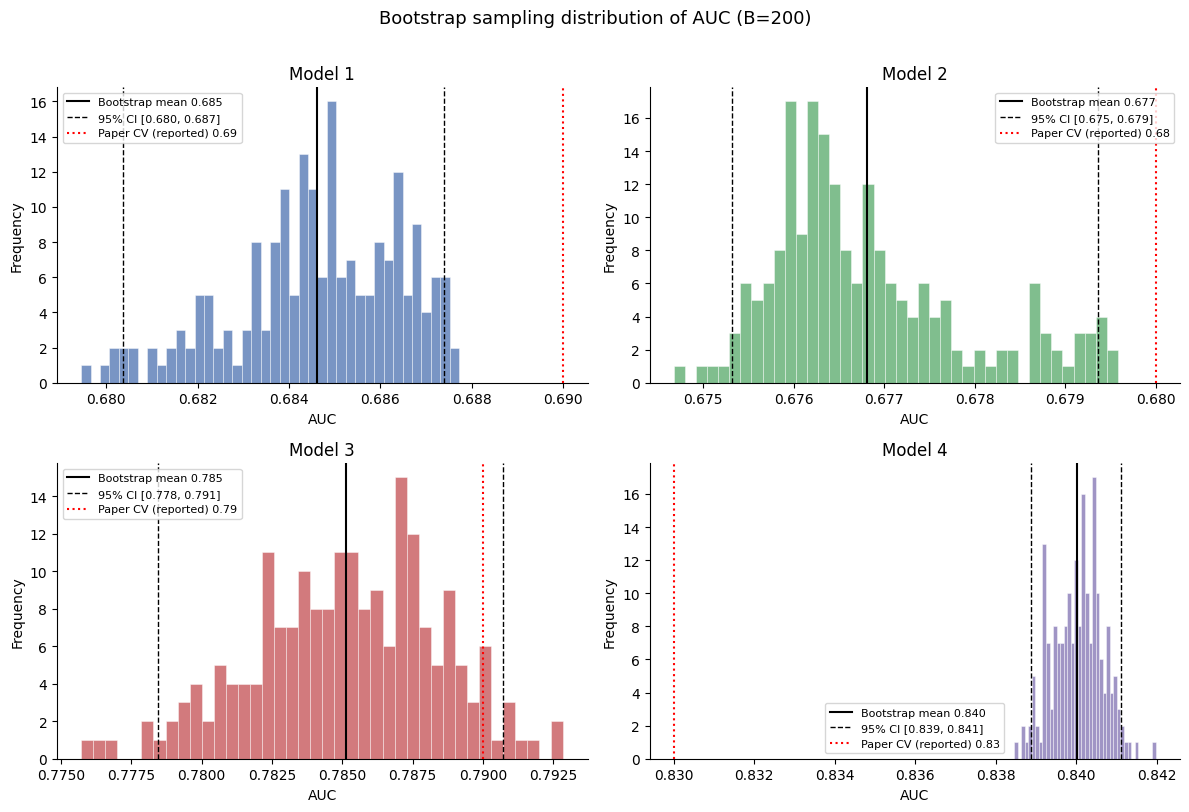

Saved: bootstrap_auc_distributions.png


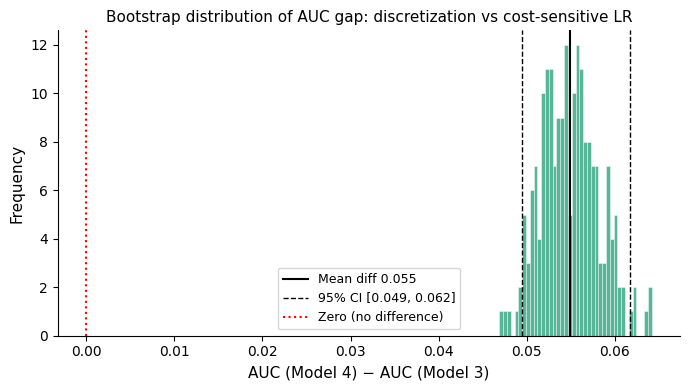

Saved: bootstrap_auc_diff_m4_m3.png


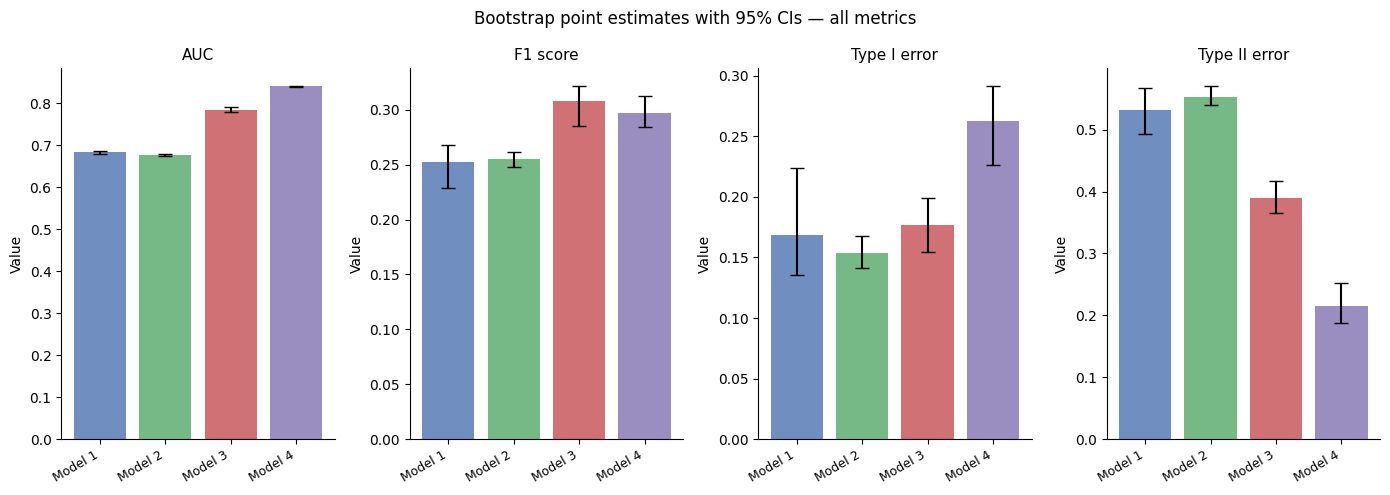

Saved: bootstrap_all_metrics_ci.png

=== ALL BLOCKS COMPLETE ===
Outputs: bootstrap_auc_distributions.png, bootstrap_auc_diff_m4_m3.png, bootstrap_all_metrics_ci.png


In [13]:
# =============================================================================
# BLOCK 7 — Summary comparison table + plots (FIXED)
# =============================================================================

# --- Ensure corrected_auc exists (safe fallback if not computed earlier) ---
if 'corrected_auc' not in globals():
    corrected_auc = {name: np.nan for name in MODELS}

print("\n" + "="*60)
print("SUMMARY — Paper CV vs Bootstrap mean vs .632+ corrected AUC")
print("="*60)

paper_cv = {'Model 1': 0.69, 'Model 2': 0.68, 'Model 3': 0.79, 'Model 4': 0.83}

rows = []
for name in MODELS:
    mean_b, lo_b, hi_b = boot_summary[name]['auc']

    corr = corrected_auc.get(name, np.nan)

    # --- Correct optimism definition ---
    optimism = corr - mean_b if not np.isnan(corr) else np.nan

    cv = paper_cv[name]

    rows.append({
        'Model'           : name,
        'Paper CV AUC'    : cv,
        'Bootstrap mean'  : round(mean_b, 4),
        '95% CI low'      : round(lo_b,   4),
        '95% CI high'     : round(hi_b,   4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())


# --- Figure 1: Bootstrap AUC distributions (4 histograms) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), tight_layout=True)
axes = axes.ravel()

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, name in enumerate(MODELS):
    ax = axes[i]

    vals = boot_metrics[name]['auc']
    vals = vals[~np.isnan(vals)]   # safety

    mean_b, lo_b, hi_b = boot_summary[name]['auc']
    corr = corrected_auc.get(name, np.nan)

    ax.hist(vals, bins=40, color=colors[i], alpha=0.75,
            edgecolor='white', linewidth=0.4)

    ax.axvline(mean_b, color='black', lw=1.5,
               label=f'Bootstrap mean {mean_b:.3f}')
    ax.axvline(lo_b, color='black', lw=1, ls='--',
               label=f'95% CI [{lo_b:.3f}, {hi_b:.3f}]')
    ax.axvline(hi_b, color='black', lw=1, ls='--')

    ax.axvline(paper_cv[name], color='red', lw=1.5, ls=':',
               label=f'Paper CV (reported) {paper_cv[name]:.2f}')

    # --- Plot .632+ only if available ---
    if not np.isnan(corr):
        ax.axvline(corr, color='orange', lw=1.5, ls='-.',
                   label=f'.632+ {corr:.3f}')

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('AUC', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle(f'Bootstrap sampling distribution of AUC (B={B})', fontsize=13, y=1.01)

plt.savefig('bootstrap_auc_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bootstrap_auc_distributions.png")


# --- Figure 2: AUC difference M4 - M3 ---
fig2, ax2 = plt.subplots(figsize=(7, 4), tight_layout=True)

diff_vals = diff_m4_m3[~np.isnan(diff_m4_m3)]

ax2.hist(diff_vals, bins=40, color='#1D9E75', alpha=0.75,
         edgecolor='white', linewidth=0.4)

ax2.axvline(diff_mean, color='black', lw=1.5,
            label=f'Mean diff {diff_mean:.3f}')
ax2.axvline(diff_lo, color='black', lw=1, ls='--',
            label=f'95% CI [{diff_lo:.3f}, {diff_hi:.3f}]')
ax2.axvline(diff_hi, color='black', lw=1, ls='--')

ax2.axvline(0, color='red', lw=1.5, ls=':',
            label='Zero (no difference)')

ax2.set_xlabel('AUC (Model 4) − AUC (Model 3)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Bootstrap distribution of AUC gap: discretization vs cost-sensitive LR', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.savefig('bootstrap_auc_diff_m4_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bootstrap_auc_diff_m4_m3.png")


# --- Figure 3: CI comparison across all metrics ---
fig3, axes3 = plt.subplots(1, 4, figsize=(14, 5), tight_layout=True)

metric_labels = {'auc': 'AUC', 'f1': 'F1 score',
                 'type1': 'Type I error', 'type2': 'Type II error'}

model_names = list(MODELS.keys())
x = np.arange(len(model_names))

for j, (k, label) in enumerate(metric_labels.items()):
    ax = axes3[j]

    means = [boot_summary[n][k][0] for n in model_names]
    los   = [boot_summary[n][k][1] for n in model_names]
    his   = [boot_summary[n][k][2] for n in model_names]

    errs  = [np.array(means) - np.array(los),
             np.array(his)   - np.array(means)]

    ax.bar(x, means, yerr=errs, color=colors, alpha=0.8,
           error_kw={'elinewidth': 1.5, 'capsize': 5, 'ecolor': 'black'})

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Value')
    ax.spines[['top','right']].set_visible(False)

fig3.suptitle('Bootstrap point estimates with 95% CIs — all metrics', fontsize=12)

plt.savefig('bootstrap_all_metrics_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bootstrap_all_metrics_ci.png")

print("\n=== ALL BLOCKS COMPLETE ===")
print("Outputs: bootstrap_auc_distributions.png, bootstrap_auc_diff_m4_m3.png, bootstrap_all_metrics_ci.png")


SUMMARY — Delete-d Jackknife estimates
         Paper CV AUC  Jackknife mean  95% CI low  95% CI high
Model                                                         
Model 1          0.69          0.6860      0.6807       0.6873
Model 2          0.68          0.6762      0.6753       0.6792
Model 3          0.79          0.7846      0.7779       0.7918
Model 4          0.83          0.8409      0.8387       0.8411


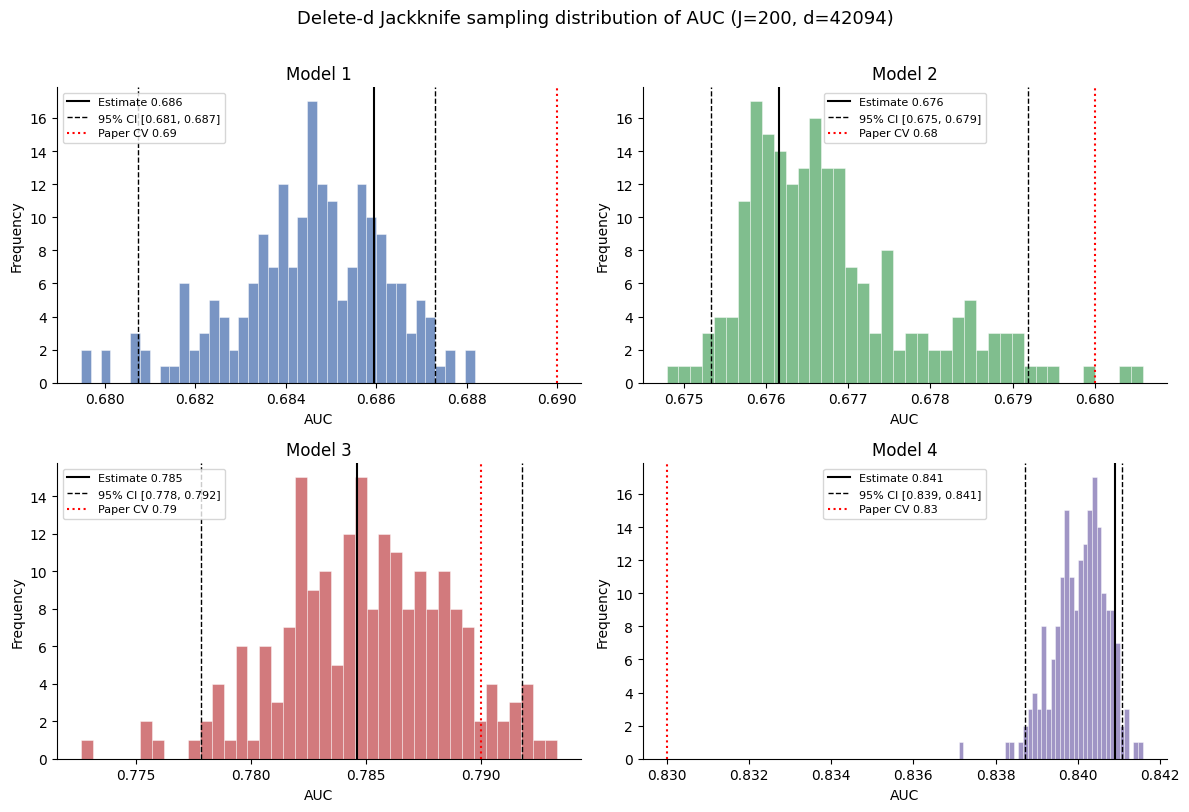

Saved: jackknife_auc_distributions.png


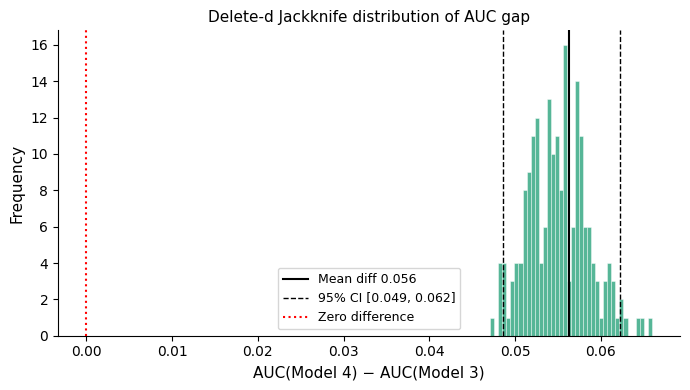

Saved: jackknife_auc_diff_m4_m3.png


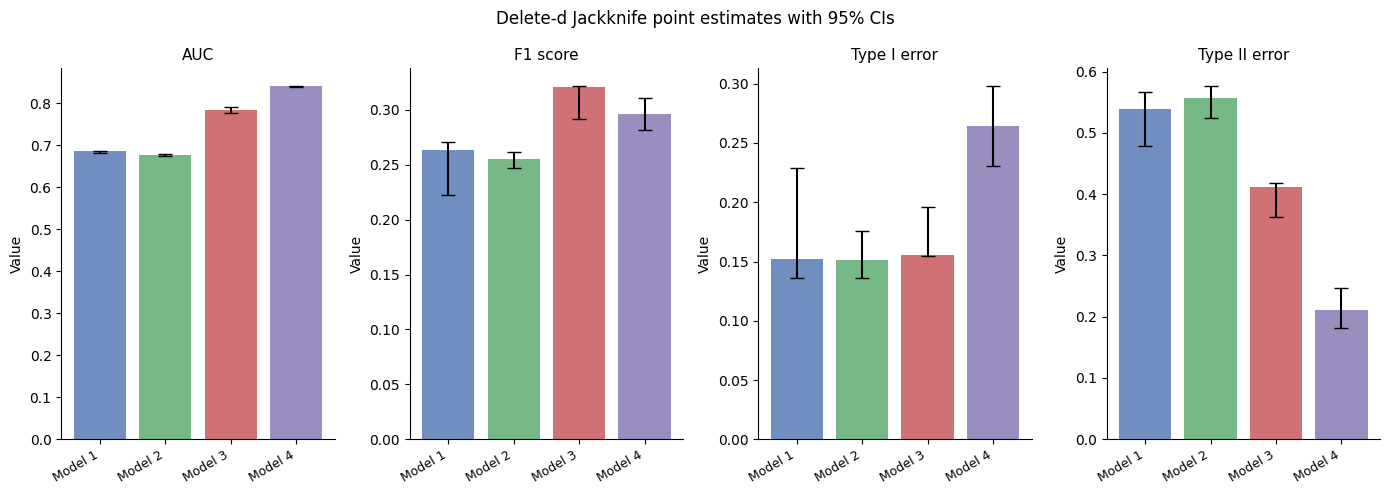

Saved: jackknife_all_metrics_ci.png

=== DELETE-d JACKKNIFE COMPLETE ===
Outputs: jackknife_auc_distributions.png, jackknife_auc_diff_m4_m3.png, jackknife_all_metrics_ci.png


In [32]:
# =============================================================================
# BLOCK 7B — Delete-d Jackknife plots
# =============================================================================

print("\n" + "="*60)
print("SUMMARY — Delete-d Jackknife estimates")
print("="*60)

paper_cv = {
    'Model 1': 0.69,
    'Model 2': 0.68,
    'Model 3': 0.79,
    'Model 4': 0.83
}

# ---------------------------------------------------------------------
# SUMMARY TABLE
# ---------------------------------------------------------------------
rows = []

for name in MODELS:
    mean_j, lo_j, hi_j = jackknife_summary[name]['auc']

    rows.append({
        'Model'          : name,
        'Paper CV AUC'   : paper_cv[name],
        'Jackknife mean' : round(mean_j, 4),
        '95% CI low'     : round(lo_j, 4),
        '95% CI high'    : round(hi_j, 4),
    })

jack_summary_df = pd.DataFrame(rows).set_index('Model')
print(jack_summary_df.to_string())

# =============================================================================
# FIGURE 1 — AUC sampling distributions
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8), tight_layout=True)
axes  = axes.ravel()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, name in enumerate(MODELS):
    ax = axes[i]

    vals = np.array(jack_vals[name]['auc'])          # <-- fixed: jack_vals

    mean_j, lo_j, hi_j = jackknife_summary[name]['auc']

    ax.hist(vals, bins=40, color=colors[i], alpha=0.75,
            edgecolor='white', linewidth=0.4)

    ax.axvline(mean_j, color='black', lw=1.5,
               label=f'Estimate {mean_j:.3f}')
    ax.axvline(lo_j,   color='black', lw=1, ls='--',
               label=f'95% CI [{lo_j:.3f}, {hi_j:.3f}]')
    ax.axvline(hi_j,   color='black', lw=1, ls='--')
    ax.axvline(paper_cv[name], color='red', lw=1.5, ls=':',
               label=f'Paper CV {paper_cv[name]:.2f}')

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('AUC', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    f'Delete-d Jackknife sampling distribution of AUC (J={J}, d={d})',
    fontsize=13, y=1.01
)
plt.savefig('jackknife_auc_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: jackknife_auc_distributions.png")


# =============================================================================
# FIGURE 2 — AUC difference: Model 4 − Model 3
# =============================================================================

fig2, ax2 = plt.subplots(figsize=(7, 4), tight_layout=True)

m4_vals = np.array(jack_vals['Model 4']['auc'])      # <-- fixed: jack_vals
m3_vals = np.array(jack_vals['Model 3']['auc'])      # <-- fixed: jack_vals

diff_vals  = m4_vals - m3_vals
theta_diff = theta_hat['Model 4']['auc'] - theta_hat['Model 3']['auc']

# ---------------------------------------------------------------------
# Correct delete-d CI for the difference  (same formula as Block 5B)
# scale = sqrt(d / (n - d))  already defined
# ---------------------------------------------------------------------
diffs  = diff_vals - theta_diff

q_lo   = np.percentile(diffs, 100 * alpha / 2)
q_hi   = np.percentile(diffs, 100 * (1 - alpha / 2))

diff_lo = theta_diff + scale * q_lo                  # <-- fixed
diff_hi = theta_diff + scale * q_hi                  # <-- fixed

ax2.hist(diff_vals, bins=40, color='#1D9E75', alpha=0.75,
         edgecolor='white', linewidth=0.4)

ax2.axvline(theta_diff, color='black', lw=1.5,
            label=f'Mean diff {theta_diff:.3f}')
ax2.axvline(diff_lo, color='black', lw=1, ls='--',
            label=f'95% CI [{diff_lo:.3f}, {diff_hi:.3f}]')
ax2.axvline(diff_hi, color='black', lw=1, ls='--')
ax2.axvline(0, color='red', lw=1.5, ls=':', label='Zero difference')

ax2.set_xlabel('AUC(Model 4) − AUC(Model 3)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Delete-d Jackknife distribution of AUC gap', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.savefig('jackknife_auc_diff_m4_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: jackknife_auc_diff_m4_m3.png")


# =============================================================================
# FIGURE 3 — CI comparison across all metrics
# =============================================================================

fig3, axes3 = plt.subplots(1, 4, figsize=(14, 5), tight_layout=True)

metric_labels = {
    'auc'   : 'AUC',
    'f1'    : 'F1 score',
    'type1' : 'Type I error',
    'type2' : 'Type II error'
}

model_names = list(MODELS.keys())
x = np.arange(len(model_names))

for j, (k, label) in enumerate(metric_labels.items()):
    ax = axes3[j]

    means = [jackknife_summary[n][k][0] for n in model_names]
    los   = [jackknife_summary[n][k][1] for n in model_names]
    his   = [jackknife_summary[n][k][2] for n in model_names]

    errs = [
        np.array(means) - np.array(los),
        np.array(his)   - np.array(means)
    ]

    ax.bar(x, means, yerr=errs, color=colors, alpha=0.8,
           error_kw={'elinewidth': 1.5, 'capsize': 5, 'ecolor': 'black'})

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Value')
    ax.spines[['top', 'right']].set_visible(False)

fig3.suptitle('Delete-d Jackknife point estimates with 95% CIs', fontsize=12)
plt.savefig('jackknife_all_metrics_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: jackknife_all_metrics_ci.png")

print("\n=== DELETE-d JACKKNIFE COMPLETE ===")
print("Outputs: jackknife_auc_distributions.png, "
      "jackknife_auc_diff_m4_m3.png, jackknife_all_metrics_ci.png")

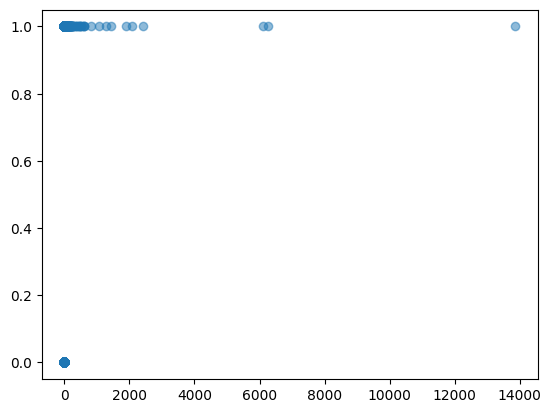

In [7]:
import numpy as np
import matplotlib.pyplot as plt

BETA0, BETA1 = -2.2, 1.8

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def generate_data(n, seed=None):
    """
    Change 2: nonlinear DGP that discretisation genuinely helps.
    X ~ Lognormal(0, 1)  →  log(X) is standard normal.
    True score is a piecewise-nonlinear function of X:
        logit(p) = beta0 + beta1 * log(X) + beta2 * log(X)^2
    A plain linear-in-X model misses the curvature; binning X (or log X)
    recovers the nonlinearity without requiring the correct functional form.
    """
    rng = np.random.default_rng(seed)
    X   = rng.lognormal(mean=0.0, sigma=3.0, size=n)   # heavy-tailed, positive
    lX  = np.log(X)                                     # back to ~N(0,1)
    p   = sigmoid(BETA0 + BETA1 * lX + 0.8 * lX ** 2)  # quadratic on log scale
    Y   = rng.binomial(1, p)
    return X.reshape(-1, 1), Y
data = generate_data(1000, seed=42)
plt.plot(data[0], data[1], 'o', alpha=0.5)
# plt.hist(data[0], bins=10, color='skyblue', edgecolor='white')
plt.show()